In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_path = "/content/drive/MyDrive/Diabetic_Retnopathy"
os.makedirs(save_path, exist_ok=True)

Mounted at /content/drive


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!pip install -q kaggle

!kaggle datasets download -d ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy

!unzip -q /content/eyepacs-aptos-messidor-diabetic-retinopathy.zip "augmented_resized_V2/*" -d /content/

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/ascanipek/eyepacs-aptos-messidor-diabetic-retinopathy
License(s): other
100% 20.5G/20.5G [02:49<00:00, 130MB/s] 



In [ ]:
!ls /content/augmented_resized_V2
!ls /content/augmented_resized_V2/train

test  train  val
0  1  2  3  4


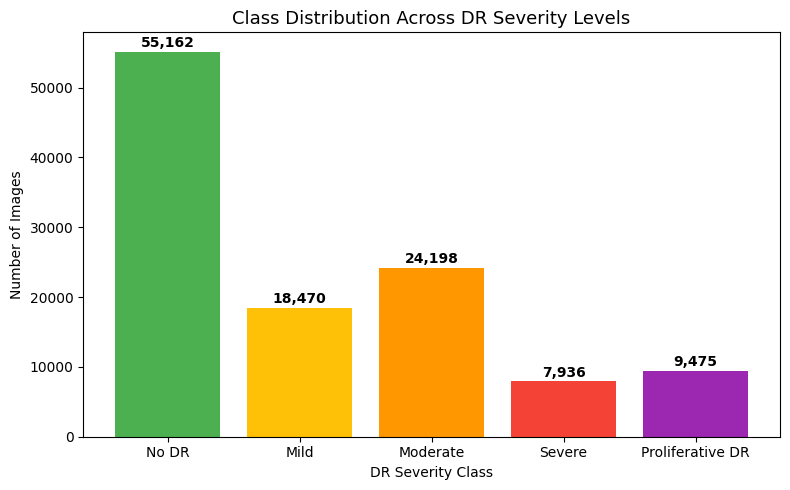

Saved to Drive!


In [ ]:
import os
import matplotlib.pyplot as plt

# Define paths inline (train_path not defined yet at this point)
base = "/content/augmented_resized_V2"
train_path = base + "/train"

# Count images per class folder
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
class_folders = sorted(os.listdir(train_path))  # folders named 0,1,2,3,4

counts = [len(os.listdir(os.path.join(train_path, folder))) for folder in class_folders]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(class_names, counts, color=['#4CAF50','#FFC107','#FF9800','#F44336','#9C27B0'])

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
             f'{count:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Class Distribution Across DR Severity Levels", fontsize=13)
plt.xlabel("DR Severity Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Diabetic_Retnopathy/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to Drive!")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision

from sklearn.metrics import classification_report, confusion_matrix, f1_score

mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision:", mixed_precision.global_policy())

Mixed precision: <DTypePolicy "mixed_float16">


In [ ]:
base = "/content/augmented_resized_V2"

train_path = base + "/train"
val_path   = base + "/val"
test_path  = base + "/test"

In [ ]:
IMG_SIZE = 256
BATCH = 512
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical'
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical'
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH,
    label_mode='categorical',
    shuffle=False
)

# Apply preprocessing with parallel calls
train_data = train_data.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

val_data = val_data.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

test_data = test_data.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=AUTOTUNE
)

# ONLY prefetch (NO cache)
train_data = train_data.prefetch(AUTOTUNE)
val_data   = val_data.prefetch(AUTOTUNE)
test_data  = test_data.prefetch(AUTOTUNE)

print("Fast pipeline ready (no caching).")

Found 115241 files belonging to 5 classes.
Found 14227 files belonging to 5 classes.
Found 14201 files belonging to 5 classes.
Fast pipeline ready (no caching).


In [ ]:
def build_model(model_type="b0", img_size=224):

    if model_type == "b0":
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(img_size, img_size, 3)
        )
    elif model_type == "b3":
        base_model = EfficientNetB3(
            weights='imagenet',
            include_top=False,
            input_shape=(img_size, img_size, 3)
        )
    else:
        raise ValueError("Choose 'b0' or 'b3'")

    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(5, activation='softmax', dtype='float32')(x)

    model = Model(base_model.input, output)
    return model

In [ ]:
model = build_model("b3", IMG_SIZE)

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-3),
    loss=loss_fn,
    metrics=['accuracy']
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        960 │ block1a_se_excit

 Total params: 11,178,292 (42.64 MB)

 Trainable params: 394,757 (1.51 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{save_path}/efficientnet_b0_best.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )
]

In [ ]:
model.fit(train_data, epochs=1, steps_per_epoch=20)

20/20 ━━━━━━━━━━━━━━━━━━━━ 200s 132ms/step - accuracy: 0.3893 - loss: 1.6818


In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.5879 - loss: 1.1885
Epoch 1: val_loss improved from inf to 1.03520, saving model to /content/drive/MyDrive/Diabetic_Retnopathy_Dataset/efficientnet_b0_best.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.5880 - loss: 1.1884 - val_accuracy: 0.6754 - val_loss: 1.0352 - learning_rate: 0.0020
Epoch 2/10
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6299 - loss: 1.1092
Epoch 2: val_loss improved from 1.03520 to 1.03171, saving model to /content/drive/MyDrive/Diabetic_Retnopathy_Dataset/efficientnet_b0_best.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.6299 - loss: 1.1091 - val_accuracy: 0.6747 - val_loss: 1.0317 - learning_rate: 0.0020
Epoch 3/10
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.6455 - loss: 1.0875
Epoch 3: val_loss improved from 1.03171 to 1.01058, saving model to /content/drive/MyDrive/Diabetic_Retnopathy_Dataset/efficientnet_b0_best.keras
226/226 ━━━━━━━━

In [ ]:
# Unfreeze last 50 layers
for layer in model.layers:
    layer.trainable = True

for layer in model.layers[:-100]:
    layer.trainable = False

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(
    optimizer=tf.keras.optimizers.Adam(2e-5),
    loss=loss_fn,
    metrics=['accuracy']
)

In [ ]:
history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.5146 - loss: 1.5390
Epoch 1: val_loss did not improve from 0.96354
226/226 ━━━━━━━━━━━━━━━━━━━━ 245s 583ms/step - accuracy: 0.5149 - loss: 1.5379 - val_accuracy: 0.6928 - val_loss: 1.0167 - learning_rate: 2.0000e-05
Epoch 2/15
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.6547 - loss: 1.0729
Epoch 2: val_loss did not improve from 0.96354
226/226 ━━━━━━━━━━━━━━━━━━━━ 40s 178ms/step - accuracy: 0.6548 - loss: 1.0728 - val_accuracy: 0.7122 - val_loss: 0.9800 - learning_rate: 2.0000e-05
Epoch 3/15
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.6825 - loss: 1.0253
Epoch 3: val_loss improved from 0.96354 to 0.95769, saving model to /content/drive/MyDrive/Diabetic_Retnopathy_Dataset/efficientnet_b0_best.keras
226/226 ━━━━━━━━━━━━━━━━━━━━ 42s 186ms/step - accuracy: 0.6825 - loss: 1.0252 - val_accuracy: 0.7239 - val_loss: 0.9577 - learning_rate: 2.0000e-05
Epoch 4/15
225/226 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/st

In [ ]:
model.save(f"{save_path}/efficientnet_b3_final.keras")
print("Model saved.")

Model saved.


In [ ]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/Diabetic_Retnopathy/efficientnet_b3_final.keras"
)

In [ ]:
# -----------------------
# Evaluate model
# -----------------------
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

# -----------------------
# Get predictions
# -----------------------
preds = model.predict(test_data)
preds = np.argmax(preds, axis=1)

# -----------------------
# Extract true labels
# -----------------------
y_true = []
for images, labels in test_data:
    y_true.append(labels.numpy())

y_true = np.concatenate(y_true, axis=0)
y_true = np.argmax(y_true, axis=1)

# -----------------------
# Metrics
# -----------------------
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, preds))

print("\nClassification Report:")
print(classification_report(y_true, preds))

print("Macro F1:", f1_score(y_true, preds, average='macro'))
print("Weighted F1:", f1_score(y_true, preds, average='weighted'))

28/28 ━━━━━━━━━━━━━━━━━━━━ 311s 5s/step - accuracy: 0.8524 - loss: 0.7716
Test Accuracy: 0.6772058010101318
28/28 ━━━━━━━━━━━━━━━━━━━━ 34s 697ms/step

Confusion Matrix:
[[6634   50  196    2   14]
 [ 666  823  335   17   21]
 [ 786  898  794  248  273]
 [  24  165  172  344  273]
 [  44   78  177  145 1022]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.96      0.88      6896
           1       0.41      0.44      0.42      1862
           2       0.47      0.26      0.34      2999
           3       0.46      0.35      0.40       978
           4       0.64      0.70      0.67      1466

    accuracy                           0.68     14201
   macro avg       0.56      0.54      0.54     14201
weighted avg       0.65      0.68      0.65     14201

Macro F1: 0.541773854483942
Weighted F1: 0.6516270457395807


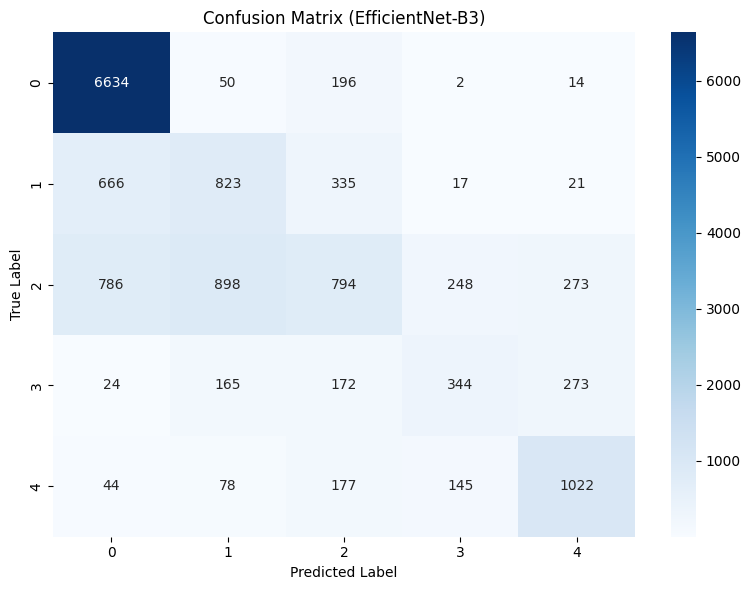

In [ ]:
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --------- Get class labels from test folder ----------
class_labels = sorted(os.listdir(test_path))

# --------- Confusion Matrix ----------
cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (EfficientNet-B3)")
plt.tight_layout()
plt.show()

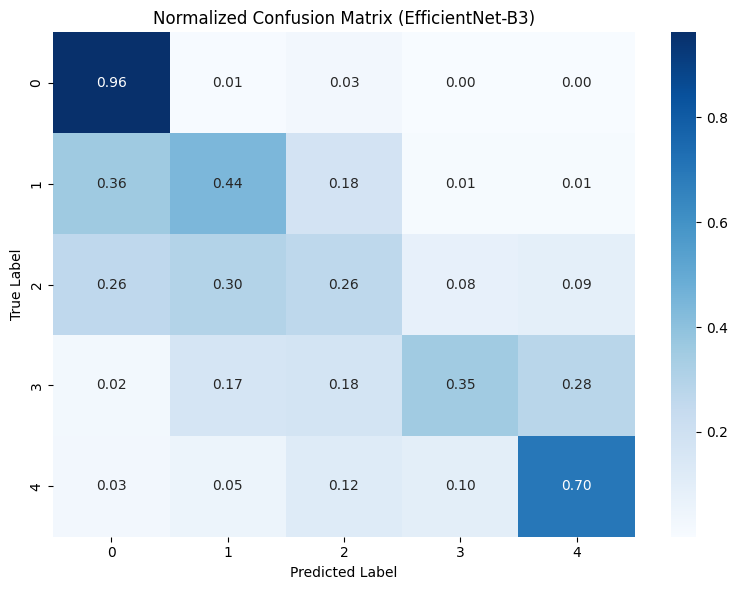

In [ ]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (EfficientNet-B3)")
plt.tight_layout()
plt.show()